# 🎨 YOLO Dataset — Beige Background + Dim Lighting
**Project:** `taabaaroboflow / spectrasence-yciia`

This notebook:
1. Installs dependencies
2. Downloads your dataset from Roboflow
3. Replaces backgrounds with beige/cream tones
4. Applies very dim lighting
5. Saves a new dataset ready to re-upload or train directly

> ⚠️ **Before running:** paste your Roboflow API key in Cell 2


In [1]:
# ════════════════════════════════════════
#   CONFIGURATION — fill these in
# ════════════════════════════════════════

ROBOFLOW_API_KEY = "uQ7xzmtQfhqKhc0bVFb3"   # ← get from roboflow.com > Settings > API
WORKSPACE        = "taabaaroboflow"
PROJECT_ID       = "spectrasence-yciia"
VERSION          = 1                      # ← change to your version number

# ── Background settings ──
BLEND_STRENGTH = 0.75   # 0.0 = no beige, 1.0 = full beige (0.75 recommended)

# ── Dim lighting settings ──
DIM_FACTOR = 0.35       # 0.0 = pitch black, 1.0 = original brightness

# ── Output folder (in Colab, saved to /content/) ──
OUTPUT_DIR = "/content/dataset_beige_dim"

print("✅ Config set!")
print(f"   Workspace  : {WORKSPACE}")
print(f"   Project    : {PROJECT_ID}")
print(f"   Version    : {VERSION}")
print(f"   Blend      : {BLEND_STRENGTH} ({int(BLEND_STRENGTH*100)}% beige)")
print(f"   Dim factor : {DIM_FACTOR} ({int((1-DIM_FACTOR)*100)}% darker than original)")


✅ Config set!
   Workspace  : taabaaroboflow
   Project    : spectrasence-yciia
   Version    : 1
   Blend      : 0.75 (75% beige)
   Dim factor : 0.35 (65% darker than original)


In [2]:
# ════════════════════════════════════════
#   STEP 1 — Install dependencies
# ════════════════════════════════════════

!pip install roboflow opencv-python numpy Pillow -q
print("✅ All packages installed!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.2 MB/s eta 0:00:00
✅ All packages installed!


In [3]:
# ════════════════════════════════════════
#   STEP 2 — Download dataset from Roboflow
# ════════════════════════════════════════

from roboflow import Roboflow
from pathlib import Path

# print(f"📥 Connecting to Roboflow...")
# rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
# project = rf.workspace(WORKSPACE).project(PROJECT_ID)
# version = project.version(VERSION)
# dataset = version.download("yolov8", location="/content/rf_dataset")

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uQ7xzmtQfhqKhc0bVFb3")
project = rf.workspace("taabaaroboflow-ibaet").project("spectrasence-yciia")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to SpectraSence-1 in yolo26:: 100%|██████████| 14235/14235 [00:03<00:00, 3892.36it/s]


In [4]:
DATASET_ROOT = Path("/content/SpectraSence-1")
print(f"\n✅ Dataset downloaded to: {DATASET_ROOT}")

# Show what splits exist
for split in ["train", "valid", "test"]:
    img_dir = DATASET_ROOT / split / "images"
    if img_dir.exists():
        count = len(list(img_dir.iterdir()))
        print(f"   {split}: {count} images")


✅ Dataset downloaded to: /content/SpectraSence-1
   train: 6226 images
   valid: 445 images
   test: 444 images


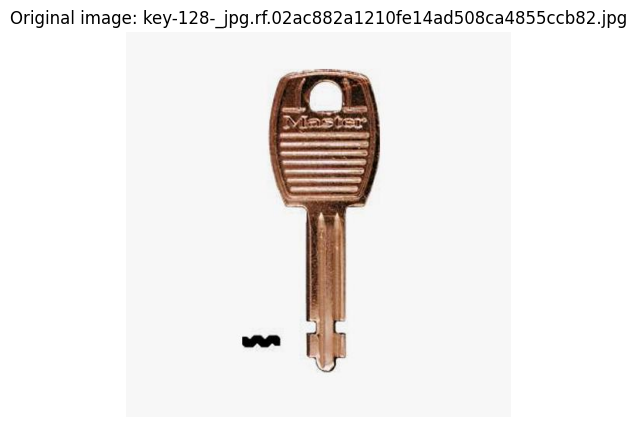

Sample: /content/SpectraSence-1/train/images/key-128-_jpg.rf.02ac882a1210fe14ad508ca4855ccb82.jpg


In [5]:
# ════════════════════════════════════════
#   STEP 3 — Preview a sample original image
# ════════════════════════════════════════

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

def find_sample_image(dataset_root):
    for split in ["train", "valid", "test"]:
        img_dir = dataset_root / split / "images"
        if img_dir.exists():
            imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
            if imgs:
                return random.choice(imgs)
    return None

sample_path = find_sample_image(DATASET_ROOT)
if sample_path:
    img = cv2.imread(str(sample_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(img_rgb)
    plt.title(f"Original image: {sample_path.name}")
    plt.axis("off")
    plt.show()
    print(f"Sample: {sample_path}")
else:
    print("No images found — check dataset download above")


In [6]:
# ════════════════════════════════════════
#   STEP 4 — Define processing functions
# ════════════════════════════════════════

import cv2
import numpy as np
import shutil
import random
from pathlib import Path

# Beige/cream color palette (RGB)
BEIGE_COLORS = [
    (235, 220, 195),   # warm classic beige
    (245, 235, 215),   # cream
    (228, 210, 185),   # darker sand beige
    (240, 225, 200),   # linen
    (232, 215, 190),   # tan
]

BOX_PADDING_PX = 4  # shrink box slightly to avoid edge bleed

def process_image(img_path, label_path, out_img_path, out_label_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return False

    h, w = img.shape[:2]

    # ── Build background mask from YOLO bounding boxes ──
    mask = np.ones((h, w), dtype=np.uint8) * 255  # all background

    if label_path.exists():
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts[:5])

            x1 = int((cx - bw / 2) * w) - BOX_PADDING_PX
            y1 = int((cy - bh / 2) * h) - BOX_PADDING_PX
            x2 = int((cx + bw / 2) * w) + BOX_PADDING_PX
            y2 = int((cy + bh / 2) * h) + BOX_PADDING_PX

            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            mask[y1:y2, x1:x2] = 0  # object region = not background

    # ── Pick random beige color ──
    beige_rgb = random.choice(BEIGE_COLORS)
    beige_bgr = (beige_rgb[2], beige_rgb[1], beige_rgb[0])
    beige_layer = np.full_like(img, beige_bgr, dtype=np.uint8)

    # ── Blend background with beige ──
    bg_mask_3ch = cv2.merge([mask, mask, mask])
    bg_mask_f   = bg_mask_3ch.astype(np.float32) / 255.0

    img_f   = img.astype(np.float32)
    beige_f = beige_layer.astype(np.float32)

    blended = img_f * (1 - BLEND_STRENGTH * bg_mask_f) + beige_f * (BLEND_STRENGTH * bg_mask_f)
    result  = np.clip(blended, 0, 255).astype(np.uint8)

    # ── Apply dim lighting to whole image ──
    result = np.clip(result.astype(np.float32) * DIM_FACTOR, 0, 255).astype(np.uint8)

    # ── Save ──
    out_img_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_img_path), result)

    if label_path.exists():
        out_label_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(label_path, out_label_path)

    return True


def process_split(dataset_root, split, out_root):
    img_dir   = Path(dataset_root) / split / "images"
    label_dir = Path(dataset_root) / split / "labels"

    if not img_dir.exists():
        print(f"  ⏭  Split '{split}' not found, skipping.")
        return 0

    out_img_dir   = Path(out_root) / split / "images"
    out_label_dir = Path(out_root) / split / "labels"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_label_dir.mkdir(parents=True, exist_ok=True)

    exts   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    images = [p for p in img_dir.iterdir() if p.suffix.lower() in exts]

    print(f"  Processing '{split}' — {len(images)} images")
    ok = 0
    for i, img_path in enumerate(images, 1):
        label_path     = label_dir / (img_path.stem + ".txt")
        out_img_path   = out_img_dir   / img_path.name
        out_label_path = out_label_dir / (img_path.stem + ".txt")

        if process_image(img_path, label_path, out_img_path, out_label_path):
            ok += 1

        if i % 100 == 0 or i == len(images):
            print(f"    [{i}/{len(images)}] ✓")

    return ok

print("✅ Functions defined and ready!")


✅ Functions defined and ready!


In [7]:
# ════════════════════════════════════════
#   STEP 5 — Process the full dataset
# ════════════════════════════════════════

import shutil
from pathlib import Path

out_root = Path(OUTPUT_DIR)
out_root.mkdir(parents=True, exist_ok=True)

total = 0
for split in ["train", "valid", "test"]:
    total += process_split(DATASET_ROOT, split, out_root)

# Copy data.yaml
for yaml_name in ["data.yaml", "dataset.yaml"]:
    src = DATASET_ROOT / yaml_name
    if src.exists():
        shutil.copy2(src, out_root / yaml_name)
        print(f"\n✅ Copied {yaml_name}")

print(f"\n{'='*50}")
print(f"  ✅ Done! {total} images processed.")
print(f"  📂 Output: {out_root}")
print(f"{'='*50}")


  Processing 'train' — 6226 images
    [100/6226] ✓
    [200/6226] ✓
    [300/6226] ✓
    [400/6226] ✓
    [500/6226] ✓
    [600/6226] ✓
    [700/6226] ✓
    [800/6226] ✓
    [900/6226] ✓
    [1000/6226] ✓
    [1100/6226] ✓
    [1200/6226] ✓
    [1300/6226] ✓
    [1400/6226] ✓
    [1500/6226] ✓
    [1600/6226] ✓
    [1700/6226] ✓
    [1800/6226] ✓
    [1900/6226] ✓
    [2000/6226] ✓
    [2100/6226] ✓
    [2200/6226] ✓
    [2300/6226] ✓
    [2400/6226] ✓
    [2500/6226] ✓
    [2600/6226] ✓
    [2700/6226] ✓
    [2800/6226] ✓
    [2900/6226] ✓
    [3000/6226] ✓
    [3100/6226] ✓
    [3200/6226] ✓
    [3300/6226] ✓
    [3400/6226] ✓
    [3500/6226] ✓
    [3600/6226] ✓
    [3700/6226] ✓
    [3800/6226] ✓
    [3900/6226] ✓
    [4000/6226] ✓
    [4100/6226] ✓
    [4200/6226] ✓
    [4300/6226] ✓
    [4400/6226] ✓
    [4500/6226] ✓
    [4600/6226] ✓
    [4700/6226] ✓
    [4800/6226] ✓
    [4900/6226] ✓
    [5000/6226] ✓
    [5100/6226] ✓
    [5200/6226] ✓
    [5300/6226] ✓
    [5400/6226] ✓
  

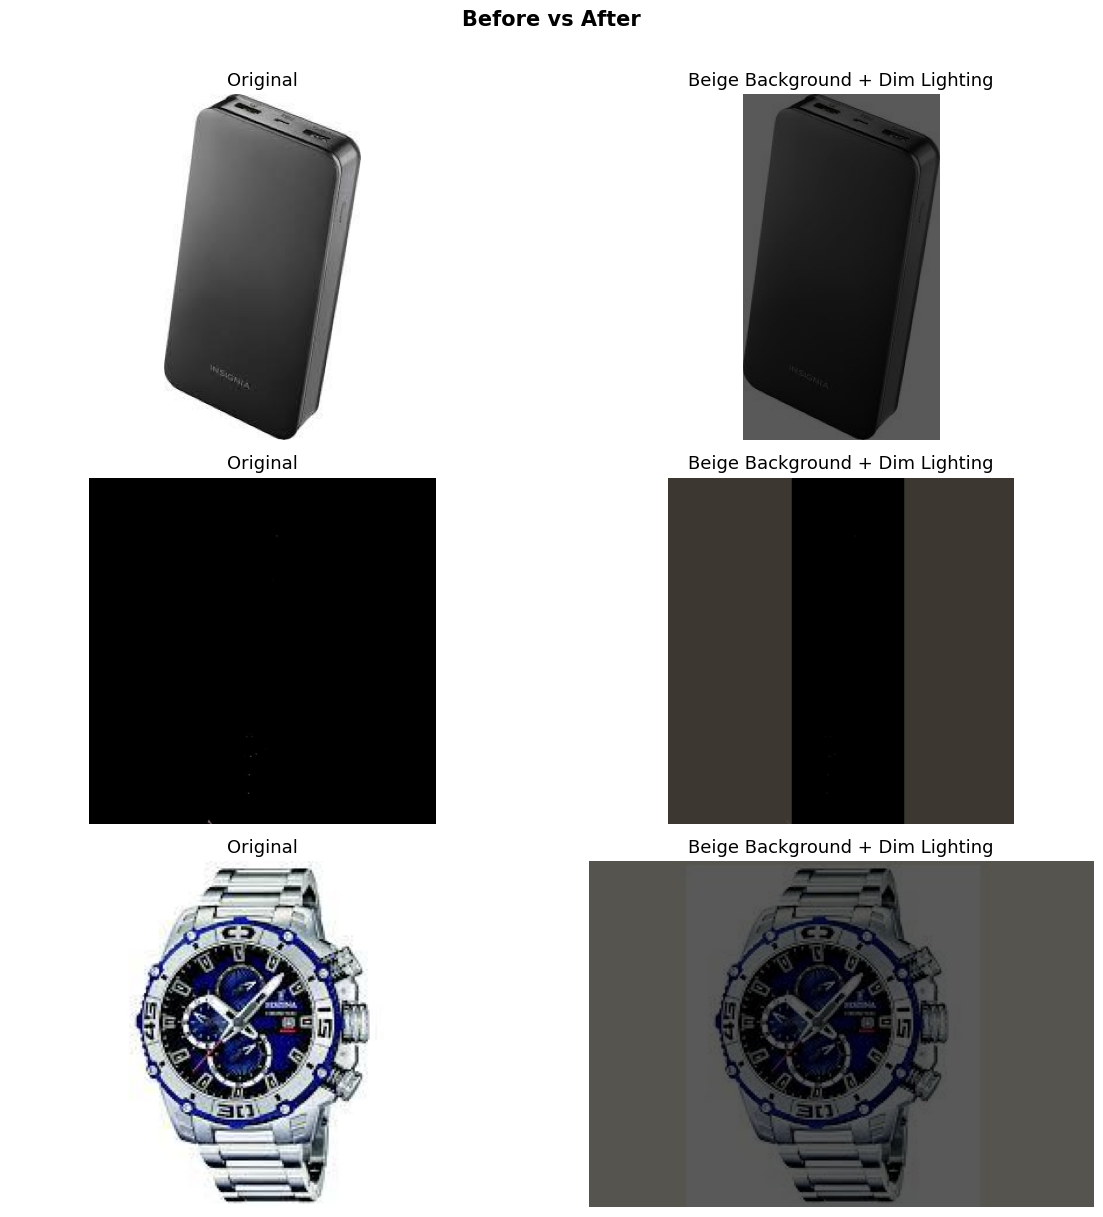

In [8]:
# ════════════════════════════════════════
#   STEP 6 — Preview: Before vs After
# ════════════════════════════════════════

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

out_root = Path(OUTPUT_DIR)

def get_pairs(dataset_root, out_root, n=3):
    pairs = []
    for split in ["train", "valid", "test"]:
        orig_dir = Path(dataset_root) / split / "images"
        new_dir  = out_root / split / "images"
        if not orig_dir.exists():
            continue
        imgs = list(orig_dir.glob("*.jpg")) + list(orig_dir.glob("*.png"))
        random.shuffle(imgs)
        for img_path in imgs[:n]:
            new_path = new_dir / img_path.name
            if new_path.exists():
                pairs.append((img_path, new_path))
        if pairs:
            break
    return pairs[:n]

pairs = get_pairs(DATASET_ROOT, out_root, n=3)

fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 4 * len(pairs)))
if len(pairs) == 1:
    axes = [axes]

for i, (orig_path, new_path) in enumerate(pairs):
    orig = cv2.cvtColor(cv2.imread(str(orig_path)), cv2.COLOR_BGR2RGB)
    new  = cv2.cvtColor(cv2.imread(str(new_path)),  cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(orig)
    axes[i][0].set_title("Original", fontsize=13)
    axes[i][0].axis("off")

    axes[i][1].imshow(new)
    axes[i][1].set_title("Beige Background + Dim Lighting", fontsize=13)
    axes[i][1].axis("off")

plt.suptitle("Before vs After", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [9]:
# ════════════════════════════════════════
#   STEP 7 — Download processed dataset as ZIP
# ════════════════════════════════════════

import shutil
from pathlib import Path
from google.colab import files

zip_path = "/content/dataset_beige_dim"
print("📦 Zipping dataset...")
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"✅ Zip created: {zip_path}.zip")

print("⬇️  Starting download...")
files.download(f"{zip_path}.zip")


📦 Zipping dataset...
✅ Zip created: /content/dataset_beige_dim.zip
⬇️  Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ════════════════════════════════════════
#   OPTIONAL — Upload processed dataset back to Roboflow
#   (creates a new project version with beige+dim images)
# ════════════════════════════════════════

# Uncomment and run this cell if you want to upload directly to Roboflow

# from roboflow import Roboflow
# from pathlib import Path

# rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
# project = rf.workspace(WORKSPACE).project(PROJECT_ID)

# out_root = Path(OUTPUT_DIR)
# for split in ["train", "valid", "test"]:
#     img_dir = out_root / split / "images"
#     if img_dir.exists():
#         imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
#         print(f"Uploading {split}: {len(imgs)} images...")
#         for img_path in imgs:
#             label_path = out_root / split / "labels" / (img_path.stem + ".txt")
#             project.upload(
#                 image_path=str(img_path),
#                 annotation_path=str(label_path) if label_path.exists() else None,
#                 split=split,
#                 num_retry_uploads=3
#             )
#         print(f"  ✅ {split} uploaded!")

# print("\n🎉 All done — check your Roboflow project!")


In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

model.train(
    data="/content/dataset_beige_dim",
    epochs=100,
    imgsz=640,
    patience=10,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_beige_dim, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78239f8f1af0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044


image 1/1 /content/dataset_beige_dim/test/images/-_202304041721041_jpg.rf.e38dfeb6e5e75b3e7f37b1031915571b.jpg: 384x640 1 Airpods case, 85.6ms
Speed: 2.9ms preprocess, 85.6ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)


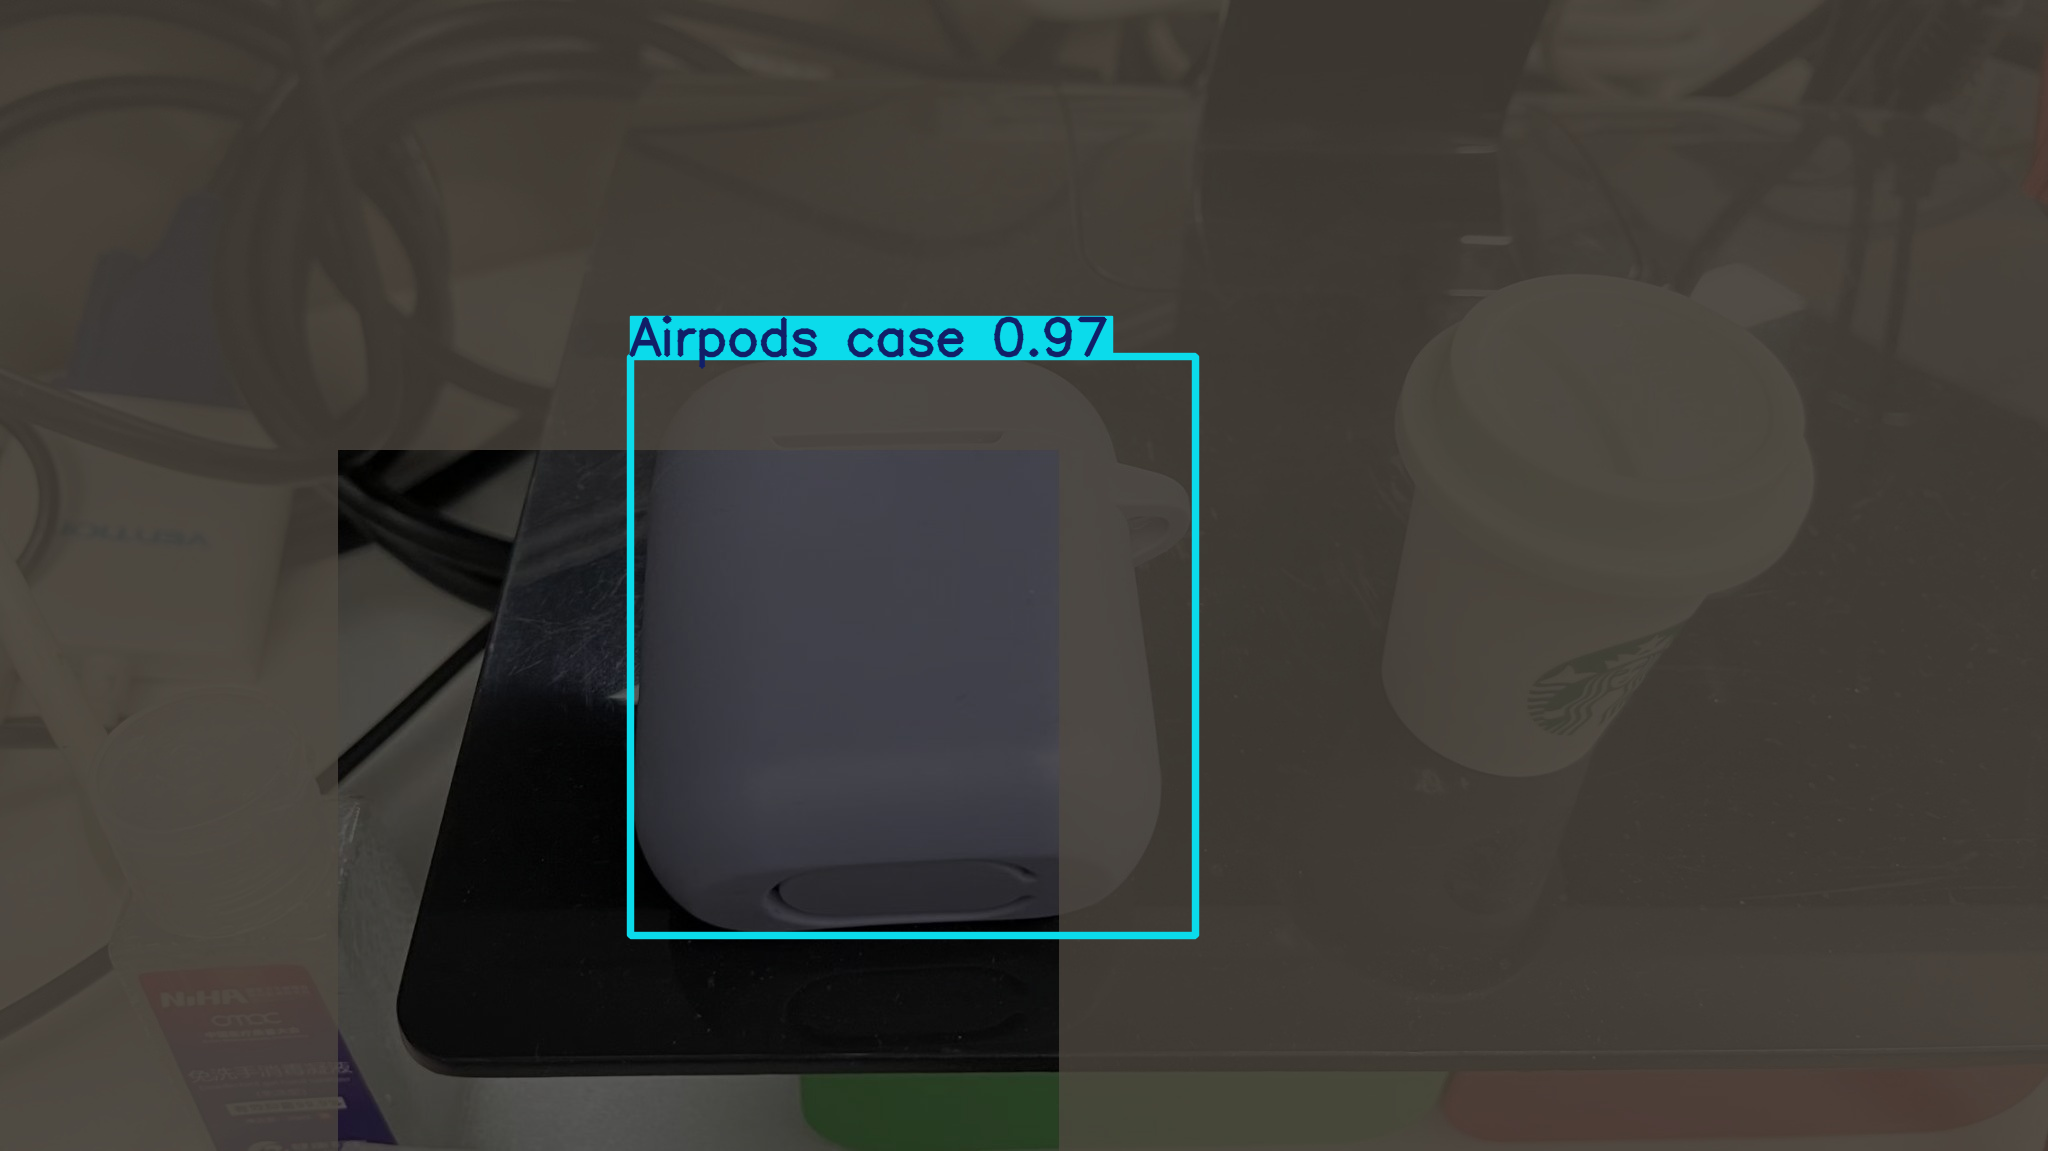

In [13]:
from google.colab.patches import cv2_imshow

# 1. Load your trained weights
model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run inference on your image
# Replace 'path_to_image.jpg' with your actual image path
results = model.predict(source='/content/dataset_beige_dim/test/images/-_202304041721041_jpg.rf.e38dfeb6e5e75b3e7f37b1031915571b.jpg', conf=0.25)

# 3. Show the result
for r in results:
    # .plot() returns a numpy array with boxes drawn
    annotated_image = r.plot()
    cv2_imshow(annotated_image)